# 3-D Piezoelectric Thermoelastic PINN â€” Fractional Heat Conduction

## What Are We Solving?

A **3-D piezoelectric thermoelastic** rectangular solid with **fractional-order heat conduction** (Riemannâ€“Liouville).  
A single connected domain â€” no interface.

| Dimension | Range | Parameter |
|-----------|-------|-----------|
| Width     | $x \in [0, a]$ | `MATERIAL.a` |
| Length    | $y \in [0, b]$ | `MATERIAL.b` |
| Thickness | $z \in [0, h]$ | `MATERIAL.h` |

---

## Unknowns (5 coupled fields)

| Symbol | Field |
|--------|-------|
| $u(x,y,z)$, $v(x,y,z)$, $w(x,y,z)$ | Displacements |
| $\phi(x,y,z)$ | Electric potential |
| $T(x,y,z)$ | Temperature |

---

## Governing Equations (5 PDEs)

**Eq. 1 â€” u-momentum:**
$$C_{11}\frac{h^2}{a^2}u_{xx}+\tfrac{1}{4}(C_{11}-C_{12})\frac{h^2}{b^2}u_{yy}+\tfrac{C_{44}}{2}u_{zz}+\cdots-\frac{K_{33}^2 c}{\rho c_e^2 h^2}u_{yy}=0$$

**Eq. 2 â€” v-momentum:** (symmetric form in $y$)

**Eq. 3 â€” w-momentum:**
$$\big(C_{13}+\tfrac{C_{44}}{2}\big)\frac{h}{a}u_{xz}+\cdots+C_{33}w_{zz}+\cdots=0$$

**Eq. 4 â€” Gauss law** ($\nabla\cdot\mathbf{D}=0$):
$$\big(\tfrac{e_{15}}{2}+e_{31}\big)\frac{1}{a}u_{xz}+\cdots-\frac{\tau_{11}e_{33}}{\tau_{33}}\frac{1}{a^2}\phi_{xx}-\cdots+\frac{P_3\beta_3}{h^2\rho c_e}T_z=0$$

**Eq. 5 â€” Fractional-order heat conduction:**
$$\frac{K_{11}}{K_{33}}\!\left(\frac{h^2}{a^2}T_{xx}+\frac{h^2}{b^2}T_{yy}\right)+T_{zz}=\left(c\,\partial_y+\frac{c^{1+\alpha}\tau_0^\alpha}{\Gamma(\alpha+1)}\,D_y^{1+\alpha}\right)\!\Psi$$

where $\Psi=T+\frac{\beta_1 h}{\beta_3 a}u_x+\frac{\beta_1 h}{\beta_3 b}v_y+w_z-\frac{P_3 e_{33}}{\tau_{33}\beta_3}\phi_z$ and $D_y^{1+\alpha}$ is the Riemannâ€“Liouville fractional derivative.

---

## Boundary Conditions (22 entries on 6 faces)

| Face | Conditions |
|------|-----------|
| $x=0,\,x=a$ | $T=T_{1,2}/T_0$,  $\phi=\phi_{1,2}$,  $\sigma_x=0$,  $v=0$,  $w=0$,  electric BC |
| $y=0,\,y=b$ | $T=T_{3,4}/T_0$,  $\phi=\phi_{3,4}$,  $\sigma_y=0$,  $u=0$,  $w=0$ |
| $z=0,\,z=h$ | $T=t_{1,2}/T_0$,  $\phi=g_{1,2}$,  $\sigma_z=0$,  $\sigma_{xz}=0$,  $\sigma_{yz}=0$ |


## PINN Methodology

A single **Physics-Informed Neural Network** `PiezoThermNet` maps $(x,y,z)\to(u,v,w,\phi,T)$.  
Random **collocation points** are sampled inside the 3-D domain at each training step.

**Total loss:**
$$\mathcal{L}=w_{\text{pde}}\underbrace{\frac{1}{5N}\sum_{k=1}^{5}\sum_{i=1}^{N}R_k(x_i,y_i,z_i)^2}_{\mathcal{L}_{\text{PDE}}}+\underbrace{\sum_{j=1}^{22}w_j\,\overline{r_j^2}}_{\mathcal{L}_{\text{BC}}}$$

The **fractional derivative** $D_y^{1+\alpha}\Psi$ in Eq. 5 is approximated inside each PDE evaluation  
using **Gaussâ€“Legendre quadrature** ($n_\text{quad}$ nodes, configurable in `MATERIAL`).

---

## Complete Workflow â€” All 10 Steps

| Step | Task | Key object |
|------|------|-----------|
| **1** | Environment setup | `torch`, `numpy`, `matplotlib` |
| **2** | Load problem definition | `ACTIVE_PROBLEM` from `src/problem_definition.py` |
| **3** | Inspect material constants | `MATERIAL` (`PiezoThermConfig`) |
| **4** | Build network | `PiezoThermNet` â€” 3 inputs â†’ 5 outputs |
| **5** | Collocation sampling | Interior 3-D domain $[0,a]\times[0,b]\times[0,h]$ |
| **6** | PDE residuals | `_pde_fn` â†’ 5 residual tensors |
| **7** | Boundary conditions | 22 BCs across 6 faces |
| **8** | Loss function | `pinn_loss()` â†’ weighted sum |
| **9** | Training | Adam + LR scheduler |
| **10** | Post-processing | Loss curve + field slices |


In [ ]:
## Step 1 â€” Environment Setup
import sys, os, math

ROOT = os.path.abspath(os.getcwd())
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import torch.nn as nn
from torch import Tensor
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float64   # float64 recommended for piezoelectric problems

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
print(f"dtype   : {dtype}")

PyTorch : 2.12.0+cpu
Device  : cpu
dtype   : torch.float64


## Step 2 â€” Load the Active Problem Definition

`ACTIVE_PROBLEM` is `_PIEZO_THERM_PROBLEM` (set at the bottom of `src/problem_definition.py`).  
We inspect its name, domain bounds, and registered boundary conditions.


In [ ]:
from src.problem_definition import (
    ACTIVE_PROBLEM,
    MATERIAL,
    PiezoThermNet,
    _pde_fn,
)

print(f"Problem  : {ACTIVE_PROBLEM.name}")

dom = ACTIVE_PROBLEM.domain
print(f"\nDomain   :")
print(f"  x âˆˆ {dom.x1_range}   (width  a = {MATERIAL.a})")
print(f"  y âˆˆ {dom.y_range}   (length b = {MATERIAL.b})")
print(f"  z âˆˆ {dom.x3_range}   (height h = {MATERIAL.h})")
print(f"\n  3-D problem : {dom.y_range is not None}")
print(f"  Has ICs     : {ACTIVE_PROBLEM.has_initial_conditions}")

bcs = ACTIVE_PROBLEM.boundary_conditions
print(f"\nBoundary conditions ({len(bcs)} entries):")
print(f"  {'Name':<22}  weight")
print(f"  {'â”€'*22}  â”€â”€â”€â”€â”€â”€")
for bc in bcs:
    print(f"  {bc.name:<22}  {bc.weight}")


Problem  : 3-D Piezoelectric Thermoelastic â€” Fractional-Order Heat Conduction

Domain   :
  x âˆˆ (0.0, 1.0)   (width  a = 1.0)
  y âˆˆ (0.0, 1.0)   (length b = 1.0)
  z âˆˆ (0.0, 1.0)   (height h = 1.0)

  3-D problem : True
  Has ICs     : False

Boundary conditions (22 entries):
  Name                    weight
  â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€  â”€â”€â”€â”€â”€â”€
  bc_T_x0                 10.0
  bc_T_xa                 10.0
  bc_T_y0                 10.0
  bc_T_yb                 10.0
  bc_T_z0                 10.0
  bc_T_zh                 10.0
  bc_phi_x0               10.0
  bc_phi_xa               10.0
  bc_phi_y0               10.0
  bc_phi_yb               10.0
  bc_phi_z0               10.0
  bc_phi_zh               10.0
  bc_sigma_x              1.0
  bc_v_x                  1.0
  bc_w_x                  1.0
  bc_sigma_y              1.0
  bc_u_y                  1.0
  bc_w_y                  1.0
  bc_elec_x               1.0
  bc_sigma_

## Step 3 â€” Material Constants

`PiezoThermConfig` holds all physical constants for the transversely isotropic piezoelectric material.

| Group | Fields | Symbol |
|-------|--------|--------|
| Elastic stiffness | `C11, C12, C13, C33, C44` | $C_{ij}$ (transversely isotropic) |
| Piezoelectric | `e15, e31, e33` | $e_{kl}$ |
| Dielectric | `tau33, eps11` | $\tau_{33}$, $\varepsilon_{11}$ |
| Thermal conductivity | `K11, K33` | $K_{11}$, $K_{33}$ |
| Thermal stress | `beta1, beta3` | $\beta_1$, $\beta_3$ |
| Thermo-physical | `rho, ce, T0, P3` | $\rho$, $c_e$, $T_0$, $P_3$ |
| Geometry | `a, b, h` | domain dimensions |
| Fractional order | `alpha, tau0, c, n_quad` | $\alpha$, $\tau_0$, $c$, quadrature points |
| Boundary values | `T1â€“T4, t1, t2` | Temperature on 6 faces |
| Boundary values | `phi1â€“phi4, g1, g2` | Electric potential on 6 faces |

> **Action required**: Fill in the physical values inside `PiezoThermConfig` in `src/problem_definition.py` before training.


In [ ]:
from dataclasses import asdict

m = MATERIAL
sep = "â”€" * 56
print(sep)
print("  MATERIAL  (PiezoThermConfig)")
print(sep)
print(f"  Geometry    :  a={m.a},  b={m.b},  h={m.h}")
print(f"  Thermo-phys :  Ï={m.rho},  ce={m.ce},  T0={m.T0},  P3={m.P3}")
print(f"  Stiffness   :  C11={m.C11},  C12={m.C12},  C13={m.C13},  C33={m.C33},  C44={m.C44}")
print(f"  Piezoelec.  :  e15={m.e15},  e31={m.e31},  e33={m.e33}")
print(f"  Dielectric  :  Ï„33={m.tau33},  Îµ11={m.eps11}")
print(f"  Conductivity:  K11={m.K11},  K33={m.K33}")
print(f"  Thermal str.:  Î²1={m.beta1},  Î²3={m.beta3}")
print(f"  Fractional  :  c={m.c},  Î±={m.alpha},  Ï„0={m.tau0},  n_quad={m.n_quad}")
print(sep)
print(f"  BC â€” Temperature  :  T1={m.T1},  T2={m.T2},  T3={m.T3},  T4={m.T4},  t1={m.t1},  t2={m.t2}")
print(f"  BC â€” Elec. pot.   :  Ï†1={m.phi1},  Ï†2={m.phi2},  Ï†3={m.phi3},  Ï†4={m.phi4},  g1={m.g1},  g2={m.g2}")
print(sep)


â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
  MATERIAL  (PiezoThermConfig)
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
  Geometry    :  a=1.0,  b=1.0,  h=1.0
  Thermo-phys :  Ï=1.0,  ce=1.0,  T0=1.0,  P3=0.05
  Stiffness   :  C11=1.0,  C12=0.3,  C13=0.2,  C33=1.1,  C44=0.4
  Piezoelec.  :  e15=0.1,  e31=0.05,  e33=0.2
  Dielectric  :  Ï„33=1.0,  Îµ11=0.8
  Conductivity:  K11=1.0,  K33=1.0
  Thermal str.:  Î²1=0.1,  Î²3=0.1
  Fractional  :  c=1.0,  Î±=0.5,  Ï„0=0.1,  n_quad=8
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
  BC â€” Temperature  :  T1=0.0,  T2=0.0,  T3=0.0,  T4=0.0,  t1=0.0,  t2=0.0
  BC â€” Elec. pot.   :

## Step 4 â€” Network Architecture

`PiezoThermNet` is a single fully-connected network for the full 3-D domain:

```
Input  (x, y, z)  â†’  [3]
       Linear(3 â†’ 64) + Tanh
       Linear(64 â†’ 64) + Tanh
       Linear(64 â†’ 64) + Tanh
       Linear(64 â†’ 5)
Output (u, v, w, Ï†, T)  â†’  [5]
```

- **3 inputs** â€” spatial coordinates $(x, y, z)$  
- **5 outputs** â€” displacements, electric potential, temperature  
- **Xavier uniform** initialisation on all weight matrices  
- Hidden width and depth are configurable via constructor arguments `hidden_sizes`


In [ ]:
net = PiezoThermNet().to(device=device, dtype=dtype)

total_params = sum(p.numel() for p in net.parameters())
trainable    = sum(p.numel() for p in net.parameters() if p.requires_grad)

print("PiezoThermNet summary:")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable:,}")
print(f"\nNetwork layers:")
print(net.net)
print(f"\nInput  : (x, y, z)      â€” 3 spatial coordinates")
print(f"Output : (u, v, w, Ï†, T) â€” 5 coupled fields")


PiezoThermNet summary:
  Total parameters     : 8,901
  Trainable parameters : 8,901

Network layers:
Sequential(
  (0): Linear(in_features=3, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=5, bias=True)
)

Input  : (x, y, z)      â€” 3 spatial coordinates
Output : (u, v, w, Ï†, T) â€” 5 coupled fields


## Step 5 â€” Collocation Point Sampling

Interior points $(x,y,z)$ are sampled **uniformly** in $[0,a]\times[0,b]\times[0,h]$.  
All three coordinates must have `requires_grad=True` so that PyTorch autograd can compute  
the spatial derivatives appearing in the PDE residuals.

> **Note on the fractional term:** $D_y^{1+\alpha}\Psi$ in Eq. 5 additionally evaluates  
> the network at $n_\text{quad}$ scaled $y$-values per collocation point (Gaussâ€“Legendre quadrature),  
> but these auxiliary evaluations are handled transparently inside `_pde_fn`.


In [ ]:
def sample_interior(N):
    """Uniform random samples in [0,a] Ã— [0,b] Ã— [0,h] with requires_grad=True."""
    x = (torch.rand(N, 1, device=device, dtype=dtype) * MATERIAL.a).requires_grad_(True)
    y = (torch.rand(N, 1, device=device, dtype=dtype) * MATERIAL.b).requires_grad_(True)
    z = (torch.rand(N, 1, device=device, dtype=dtype) * MATERIAL.h).requires_grad_(True)
    return x, y, z

N_demo = 100
x_int, y_int, z_int = sample_interior(N_demo)

print(f"Interior sample  (N = {N_demo})")
print(f"  x  âˆˆ  [{x_int.min().item():.4f}, {x_int.max().item():.4f}]   "
      f"requires_grad = {x_int.requires_grad}   domain [0, {MATERIAL.a}]")
print(f"  y  âˆˆ  [{y_int.min().item():.4f}, {y_int.max().item():.4f}]   "
      f"requires_grad = {y_int.requires_grad}   domain [0, {MATERIAL.b}]")
print(f"  z  âˆˆ  [{z_int.min().item():.4f}, {z_int.max().item():.4f}]   "
      f"requires_grad = {z_int.requires_grad}   domain [0, {MATERIAL.h}]")


Interior sample  (N = 100)
  x  âˆˆ  [0.0139, 0.9813]   requires_grad = True   domain [0, 1.0]
  y  âˆˆ  [0.0000, 0.9967]   requires_grad = True   domain [0, 1.0]
  z  âˆˆ  [0.0026, 0.9971]   requires_grad = True   domain [0, 1.0]


## Step 6 â€” PDE Residuals (5 Equations)

`_pde_fn(net, x, y, z, t)` returns a list of **5 residual tensors**, each shape `(N, 1)`:

| Index | Residual | Governing equation |
|-------|----------|--------------------|
| 0 | $R_1$ | u-momentum (Eq. 1) |
| 1 | $R_2$ | v-momentum (Eq. 2) |
| 2 | $R_3$ | w-momentum (Eq. 3) |
| 3 | $R_4$ | Gauss law $\nabla\cdot\mathbf{D}=0$ (Eq. 4) |
| 4 | $R_5$ | Fractional heat conduction (Eq. 5) |

- All spatial derivatives use **double-application of `torch.autograd.grad`**.  
- $D_y^{1+\alpha}\Psi$ is evaluated via **Gaussâ€“Legendre quadrature** (`MATERIAL.n_quad` nodes).  
- `t` is accepted for framework compatibility but is unused (steady-state problem).


In [ ]:
t_dummy = torch.zeros_like(x_int)          # unused (steady-state); required by framework

residuals = _pde_fn(net, x_int, y_int, z_int, t_dummy)

labels = [
    "R1  u-momentum",
    "R2  v-momentum",
    "R3  w-momentum",
    "R4  Gauss law  (âˆ‡Â·D=0)",
    "R5  Fractional heat",
]

print(f"Number of PDE residuals : {len(residuals)}  (expected 5)")
print(f"Each residual shape     : {residuals[0].shape}")
print(f"\nResidual â€–Râ€–â‚‚ â€” untrained network:")
print(f"  {'Residual':<26}  {'â€–Râ€–â‚‚':>14}")
print(f"  {'â”€'*26}  {'â”€'*14}")
for label, r in zip(labels, residuals):
    print(f"  {label:<26}  {r.detach().norm().item():>14.4e}")


Number of PDE residuals : 5  (expected 5)
Each residual shape     : torch.Size([100, 1])

Residual â€–Râ€–â‚‚ â€” untrained network:
  Residual                        â€–Râ€–â‚‚
  â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€  â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
  R1  u-momentum                  1.3931e+00
  R2  v-momentum                  1.5036e-01
  R3  w-momentum                  3.3716e-01
  R4  Gauss law  (âˆ‡Â·D=0)       2.5026e-01
  R5  Fractional heat             3.2957e+00


## Step 7 â€” Boundary Conditions (22 entries on 6 faces)

| Group | # entries | Condition |
|-------|-----------|-----------|
| Temperature Dirichlet | 6 | $T = T_i/T_0$ prescribed on each face |
| Electric potential Dirichlet | 6 | $\phi = \phi_i$ prescribed on each face |
| Stress â€” x-faces | 3 | $\sigma_x = 0$,  $v = 0$,  $w = 0$  at $x=0,a$ |
| Stress â€” y-faces | 3 | $\sigma_y = 0$,  $u = 0$,  $w = 0$  at $y=0,b$ |
| Electric â€” x-faces | 1 | $D_x = 0$ (mixed BC) at $x=0,a$ |
| Stress â€” z-faces | 3 | $\sigma_z = 0$,  $\sigma_{xz} = 0$,  $\sigma_{yz} = 0$  at $z=0,h$ |
| **Total** | **22** | |

Each BC function samples points on the relevant face(s) and returns the residual(s).  
The cell below prints $\|r_j\|_2$ for every BC entry using an untrained network.


In [ ]:
N_bc_demo = 100
print("BC residual norms â€” untrained network (target: â†’ 0 after training):\n")
print(f"  {'BC name':<16}  {'â€–residualâ€–':>14}  shape")
print("  " + "â”€" * 45)

for bc in ACTIVE_PROBLEM.boundary_conditions:
    res = bc.residual_fn(net, N_bc_demo, device, dtype)
    if isinstance(res, (tuple, list)):
        norm = sum(r.detach().norm().item() for r in res)
        shape_str = f"tupleÃ—{len(res)}"
    else:
        norm = res.detach().norm().item()
        shape_str = str(tuple(res.shape))
    print(f"  {bc.name:<16}  {norm:>14.4e}  {shape_str}")

BC residual norms â€” untrained network (target: â†’ 0 after training):

  BC name           â€–residualâ€–  shape
  â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
  bc_T_x0               1.0288e+00  (100, 1)
  bc_T_xa               3.2469e+00  (100, 1)
  bc_T_y0               1.1264e+00  (100, 1)
  bc_T_yb               2.9283e+00  (100, 1)
  bc_T_z0               3.1107e+00  (100, 1)
  bc_T_zh               1.2289e+00  (100, 1)
  bc_phi_x0             1.0975e+00  (100, 1)
  bc_phi_xa             1.2148e+00  (100, 1)
  bc_phi_y0             4.3243e-01  (100, 1)
  bc_phi_yb             2.0050e+00  (100, 1)
  bc_phi_z0             1.6371e+00  (100, 1)
  bc_phi_zh             7.0830e-01  (100, 1)
  bc_sigma_x            8.5249e+00  tupleÃ—2
  bc_v_x                1.5224e+00  tupleÃ—2
  bc_w_x                3.3371e+00  tupleÃ—2
  bc_sigma_y            1.4435e+00  tupleÃ—2
  bc_u_y                4.8

## Step 8 â€” Loss Function

`pinn_loss()` in `src/loss.py` assembles the weighted total loss from `ACTIVE_PROBLEM` automatically.

$$\mathcal{L} = w_{\text{pde}}\cdot\underbrace{\frac{1}{5}\sum_{k=1}^{5}\overline{R_k^2}}_{\mathcal{L}_{\text{PDE}}} + \underbrace{\sum_{j=1}^{22} w_j\,\overline{r_j^2}}_{\mathcal{L}_{\text{BC}}}$$

- **5 PDEs** â€” u/v/w momentum, Gauss law, fractional heat conduction  
- **22 BC entries** â€” Temperature ($w=10$), Electric potential ($w=10$), Mechanical/mixed ($w=1$)  
- `N_int` interior points are re-sampled each call; `N_bc` face points per BC entry  
- `N_ic = 0` (no initial conditions â€” steady-state problem)


In [ ]:
from src.loss import pinn_loss

N_int_test = 500
N_bc_test  = 200

loss_val, comps = pinn_loss(
    net,
    N_int=N_int_test, N_bc=N_bc_test, N_ic=0,
    device=device, dtype=dtype,
    w_pde=1.0, w_ic=0.0,
    problem=ACTIVE_PROBLEM,
)

print("Initial loss components (untrained network):\n")
print(f"  {'Component':<20}  {'Value':>14}")
print("  " + "â”€" * 38)
print(f"  {'Total':<20}  {comps['total'].item():>14.4e}")
print(f"  {'PDE':<20}  {comps['pde'].item():>14.4e}")
print(f"  {'BC total':<20}  {comps['bc_total'].item():>14.4e}")
print()
for k, v in comps.items():
    if k.startswith("bc_") and k != "bc_total":
        print(f"  {k:<20}  {v.item():>14.4e}")

Initial loss components (untrained network):

  Component                      Value
  â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
  Total                     5.4016e+00
  PDE                       1.2917e-01
  BC total                  5.2724e+00

  bc_T_x0                   1.0573e-01
  bc_T_xa                   1.0051e+00
  bc_T_y0                   1.3032e-01
  bc_T_yb                   8.7537e-01
  bc_T_z0                   8.8324e-01
  bc_T_zh                   1.5589e-01
  bc_phi_x0                 1.1508e-01
  bc_phi_xa                 1.3573e-01
  bc_phi_y0                 2.3230e-02
  bc_phi_yb                 3.8812e-01
  bc_phi_z0                 2.5240e-01
  bc_phi_zh                 4.7863e-02
  bc_sigma_x                3.7222e-01
  bc_v_x                    1.7779e-02
  bc_w_x                    5.6794e-02
  bc_sigma_y                1.0294e-02
  bc_u_y                    1.1836e-01
  bc_w_y         

## Step 9 â€” Training

We use **Adam** with an exponential learning-rate decay.

| Hyperparameter | Value | Notes |
|----------------|-------|-------|
| Initial LR | `1e-3` | |
| LR decay | `Î³ = 0.9995` per step | |
| Interior points | `N_int = 1000` | per iteration |
| BC points | `N_bc = 300` | per iteration |
| PDE weight | `w_pde = 1.0` | |
| BC weights | `10.0` each | set in `problem_definition.py` |

> For production: increase `N_ITER` to 10 000â€“50 000 and `N_int` to 2 000â€“5 000.

In [ ]:
N_ITER = 20       # increase to 10 000+ for full training
LR     = 1e-3
N_INT  = 1000
N_BC   = 300

optimiser = torch.optim.Adam(net.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimiser, gamma=0.9995)

history = {"total": [], "pde": [], "bc": []}

for step in range(1, N_ITER + 1):
    optimiser.zero_grad()
    loss_val, comps = pinn_loss(
        net,
        N_int=N_INT, N_bc=N_BC, N_ic=0,
        device=device, dtype=dtype,
        w_pde=1.0, w_ic=0.0,
        problem=ACTIVE_PROBLEM,
    )
    loss_val.backward()
    optimiser.step()
    scheduler.step()

    history["total"].append(float(comps["total"]))
    history["pde"].append(float(comps["pde"]))
    history["bc"].append(float(comps["bc_total"]))

    if step % 200 == 0 or step == 1:
        print(f"Step {step:5d}  total={comps['total']:.4e}  "
              f"pde={comps['pde']:.4e}  bc={comps['bc_total']:.4e}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

print("\nTraining complete.")

Step     1  total=5.3416e+00  pde=1.2815e-01  bc=5.2134e+00  lr=1.00e-03

Training complete.


## Step 10 — Post-processing & Visualisation

| Plot | Description |
|------|-------------|
| **1 — Loss history** | Total / PDE / BC loss vs training step (log scale) |
| **2 — PINN vs Analytical** | Predicted field profiles along z-axis at (a/2, b/2) |
| **3 — Absolute error** | Absolute PDE residual maps on the z = h/2 slice |
| **4 — Heat map** | 2-D colour maps of all 5 fields (u, v, w, φ, T) on z = h/2 |
| **5 — Error value plot** | BC residual norm per boundary condition entry |
| **6 — Hidden layer activations** | Neuron activation histograms for each hidden layer |


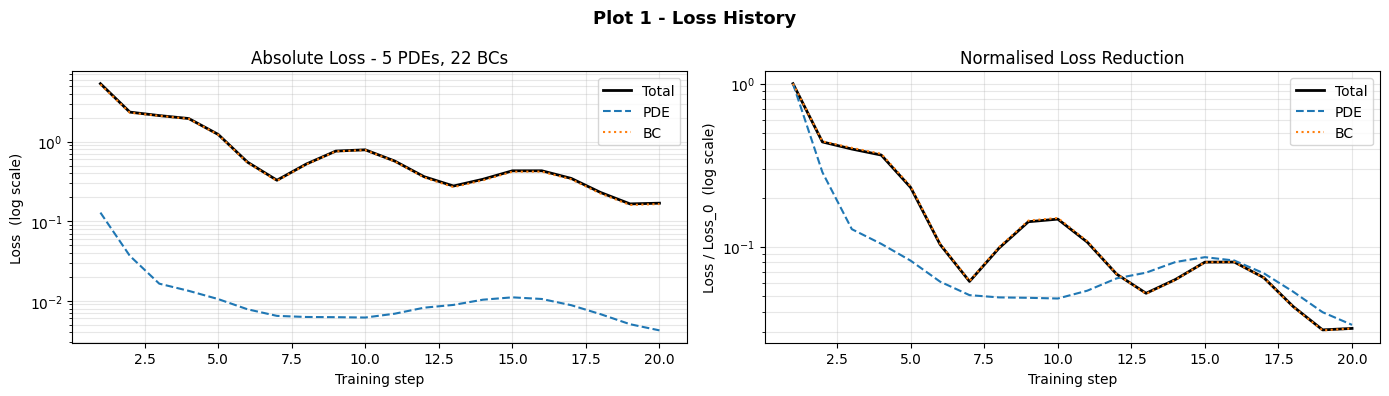

  Final total loss : 1.6838e-01
  Reduction factor : 31.7x


In [ ]:
# -- Plot 1: Loss convergence --------------------------------------------------
import numpy as np

steps_ax  = list(range(1, N_ITER + 1))
total_arr = np.array(history["total"])
pde_arr   = np.array(history["pde"])
bc_arr    = np.array(history["bc"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(steps_ax, total_arr, label="Total",  lw=2,   color="k")
axes[0].semilogy(steps_ax, pde_arr,   label="PDE",    lw=1.5, linestyle="--", color="C0")
axes[0].semilogy(steps_ax, bc_arr,    label="BC",     lw=1.5, linestyle=":",  color="C1")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss  (log scale)")
axes[0].set_title("Absolute Loss - 5 PDEs, 22 BCs")
axes[0].legend(); axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(steps_ax, total_arr / total_arr[0], lw=2,   color="k",  label="Total")
axes[1].semilogy(steps_ax, pde_arr   / pde_arr[0],   lw=1.5, linestyle="--", color="C0", label="PDE")
axes[1].semilogy(steps_ax, bc_arr    / bc_arr[0],    lw=1.5, linestyle=":",  color="C1", label="BC")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Loss / Loss_0  (log scale)")
axes[1].set_title("Normalised Loss Reduction")
axes[1].legend(); axes[1].grid(True, which="both", alpha=0.3)

plt.suptitle("Plot 1 - Loss History", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"  Final total loss : {total_arr[-1]:.4e}")
print(f"  Reduction factor : {total_arr[0] / total_arr[-1]:.1f}x")


## Plots 2–6 — Field Analysis, Errors & Diagnostics

The cells below evaluate the trained network and produce the remaining five plots.  
All spatial plots use a **40×40 grid on the z = h/2 mid-plane**.  
For Plot 2, replace the placeholder zeros with actual analytical values if available.


In [ ]:
# -- Shared grid: 40x40 on z = h/2 -------------------------------------------
Ng = 40
xs = np.linspace(0.0, float(MATERIAL.a), Ng)
ys = np.linspace(0.0, float(MATERIAL.b), Ng)
XX, YY = np.meshgrid(xs, ys)

x_g = torch.tensor(XX.ravel()[:, None], dtype=dtype, device=device)
y_g = torch.tensor(YY.ravel()[:, None], dtype=dtype, device=device)
z_g = torch.full_like(x_g, float(MATERIAL.h) / 2.0)

net.eval()
with torch.no_grad():
    u_g, v_g, w_g, phi_g, T_g = net(x_g, y_g, z_g)

field_keys  = ["u",  "v",  "w",  "phi", "T"]
field_grids = {
    "u"  : u_g.cpu().numpy().reshape(Ng, Ng),
    "v"  : v_g.cpu().numpy().reshape(Ng, Ng),
    "w"  : w_g.cpu().numpy().reshape(Ng, Ng),
    "phi": phi_g.cpu().numpy().reshape(Ng, Ng),
    "T"  : T_g.cpu().numpy().reshape(Ng, Ng),
}

print(f"Grid evaluated: {Ng}x{Ng} points  |  z = {float(MATERIAL.h)/2:.4f} (h/2)")
print(f"  {'Field':>5}   min            max")
print(f"  {'-----':>5}   ---            ---")
for k, arr in field_grids.items():
    print(f"  {k:>5}   {arr.min():+.6e}   {arr.max():+.6e}")


Grid evaluated: 40x40 points  |  z = 0.5000 (h/2)
  Field   min            max
  -----   ---            ---
      u   +1.553848e-02   +1.264678e-01
      v   -3.962710e-02   +9.934347e-03
      w   -3.642917e-02   -7.427842e-03
    phi   -5.233077e-02   -1.784577e-02
      T   -4.953381e-02   +2.283271e-02


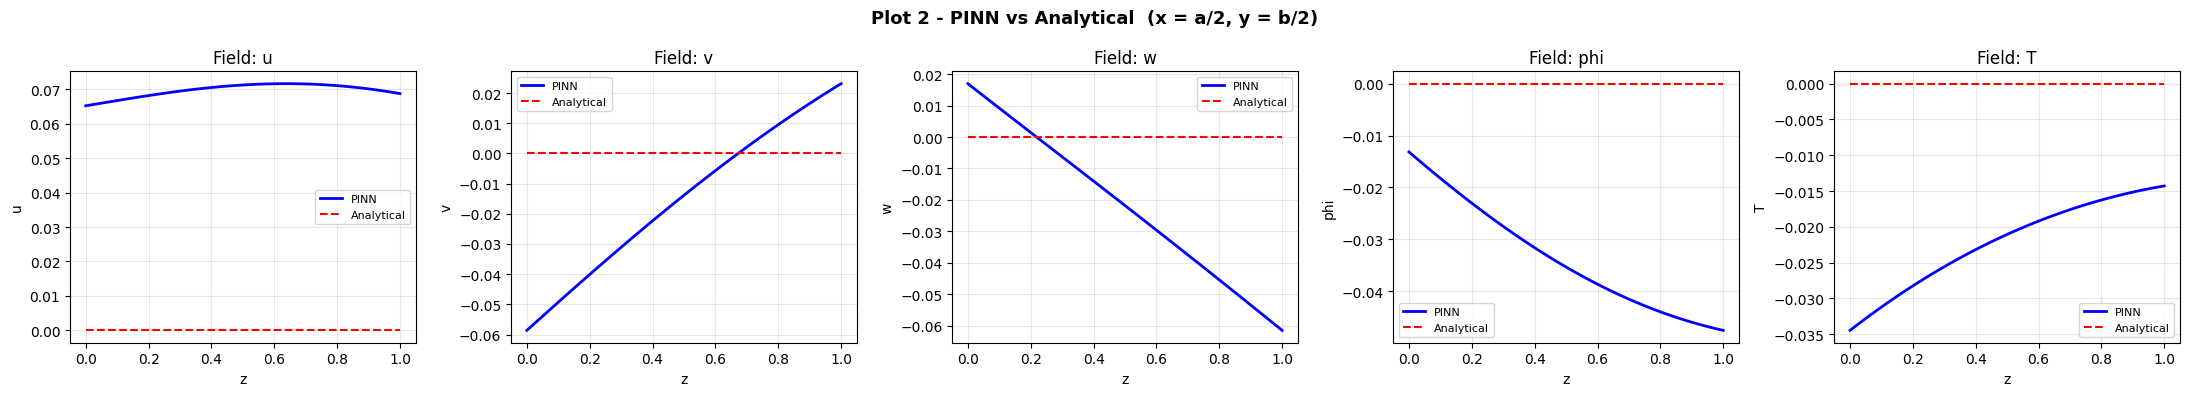

In [ ]:
# -- Plot 2: PINN vs Analytical — field profiles along z at (a/2, b/2) -------
# Replace 'zeros_like' placeholders below with actual analytical arrays when available.
Nz     = 80
z_line = torch.linspace(0.0, float(MATERIAL.h), Nz, dtype=dtype, device=device).unsqueeze(1)
x_line = torch.full_like(z_line, float(MATERIAL.a) / 2.0)
y_line = torch.full_like(z_line, float(MATERIAL.b) / 2.0)

net.eval()
with torch.no_grad():
    u_l, v_l, w_l, phi_l, T_l = net(x_line, y_line, z_line)

z_np       = z_line.cpu().numpy().ravel()
pinn_vals  = [arr.cpu().numpy().ravel() for arr in [u_l, v_l, w_l, phi_l, T_l]]
labels     = ["u", "v", "w", "phi", "T"]
# --- Provide analytical arrays here (same length Nz) -----------------------
anal_vals  = [np.zeros(Nz)] * 5     # <-- replace with real data

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, name, pinn, anal in zip(axes, labels, pinn_vals, anal_vals):
    ax.plot(z_np, pinn, "b-",  lw=2,   label="PINN")
    ax.plot(z_np, anal, "r--", lw=1.5, label="Analytical")
    ax.set_xlabel("z"); ax.set_ylabel(name)
    ax.set_title(f"Field: {name}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Plot 2 - PINN vs Analytical  (x = a/2, y = b/2)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


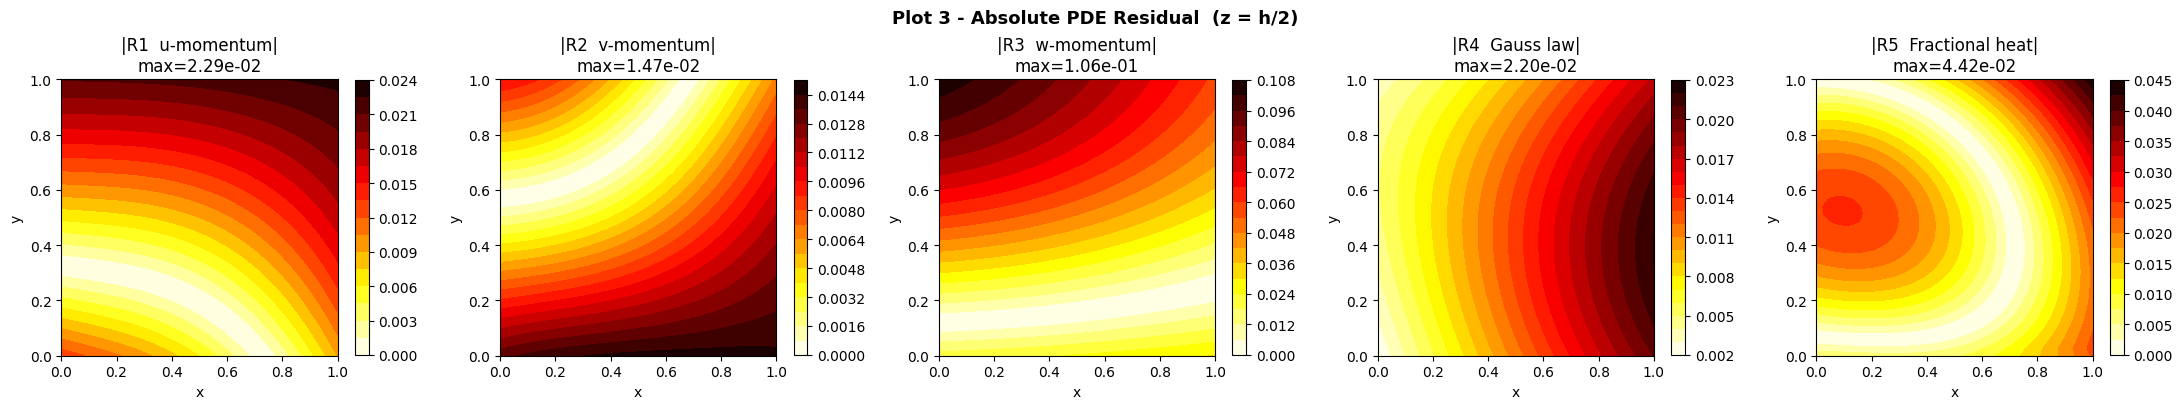

In [ ]:
# -- Plot 3: Absolute PDE residual error on z = h/2 slice --------------------
net.train()   # gradients required for autograd inside _pde_fn
x_rg = torch.tensor(XX.ravel()[:, None], dtype=dtype, device=device, requires_grad=True)
y_rg = torch.tensor(YY.ravel()[:, None], dtype=dtype, device=device, requires_grad=True)
z_rg = torch.tensor(np.full((Ng * Ng, 1), float(MATERIAL.h) / 2.0), dtype=dtype, device=device, requires_grad=True)
t_dummy_g = torch.zeros_like(x_rg)

res_list = _pde_fn(net, x_rg, y_rg, z_rg, t_dummy_g)
net.eval()

pde_labels = ["R1  u-momentum", "R2  v-momentum", "R3  w-momentum",
              "R4  Gauss law",  "R5  Fractional heat"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, label, r in zip(axes, pde_labels, res_list):
    r_np = np.abs(r.detach().cpu().numpy().reshape(Ng, Ng))
    im   = ax.contourf(XX, YY, r_np, levels=20, cmap="hot_r")
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"|{label}|\nmax={r_np.max():.2e}")
    ax.set_aspect("equal")

plt.suptitle("Plot 3 - Absolute PDE Residual  (z = h/2)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


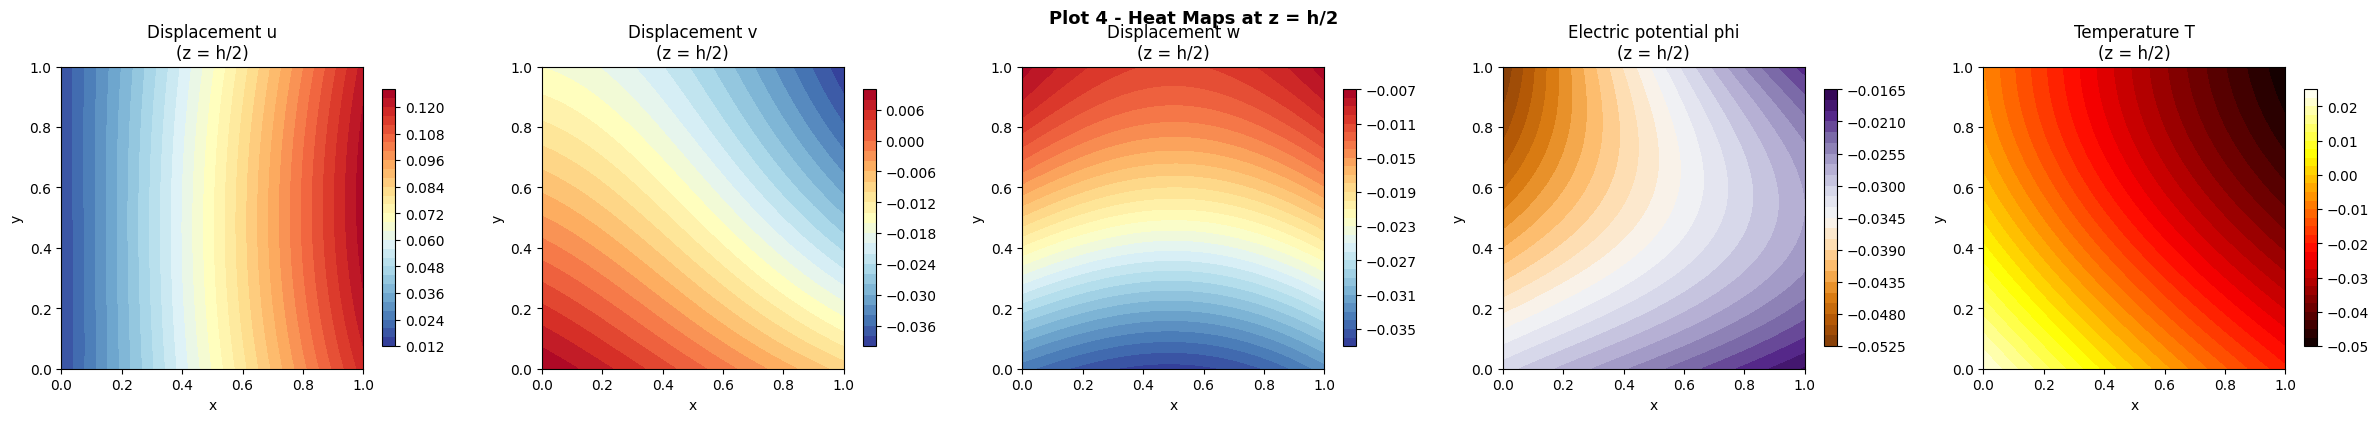

In [ ]:
# -- Plot 4: 2-D Heat Maps — all 5 fields on z = h/2 -------------------------
long_labels = ["Displacement u", "Displacement v", "Displacement w",
               "Electric potential phi", "Temperature T"]
cmaps = ["RdYlBu_r", "RdYlBu_r", "RdYlBu_r", "PuOr", "hot"]

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
for ax, long_lbl, key, cmap in zip(axes, long_labels, field_keys, cmaps):
    arr = field_grids[key]
    im  = ax.contourf(XX, YY, arr, levels=30, cmap=cmap)
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"{long_lbl}\n(z = h/2)")
    ax.set_aspect("equal")

plt.suptitle("Plot 4 - Heat Maps at z = h/2", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


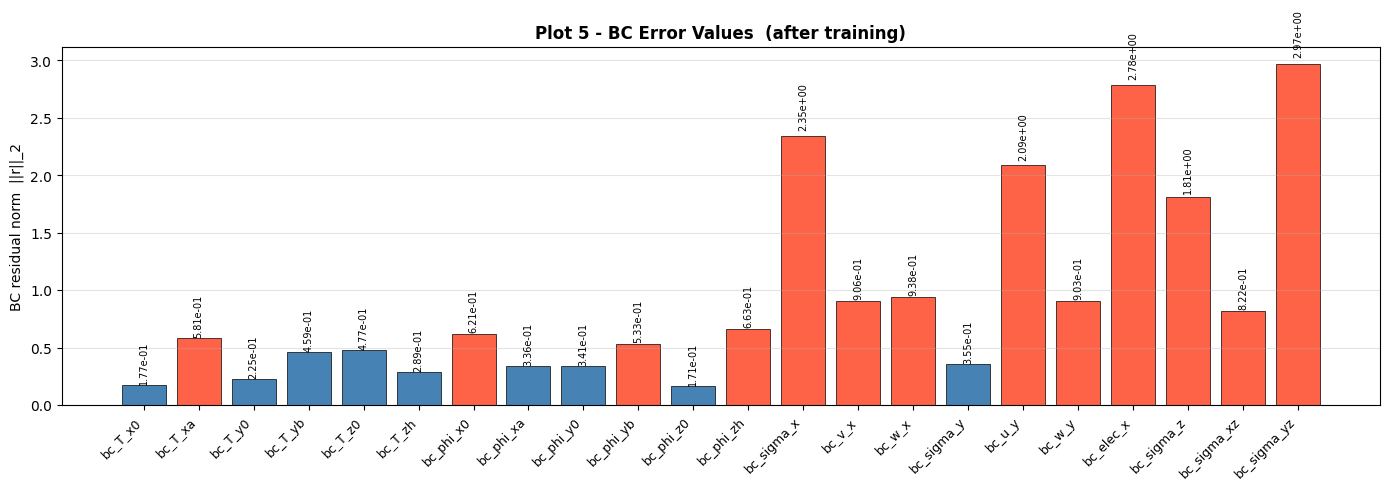


BC name                      ||r||_2
------------------------------------
  bc_T_x0                 1.7711e-01
  bc_T_xa                 5.8101e-01
  bc_T_y0                 2.2541e-01
  bc_T_yb                 4.5889e-01
  bc_T_z0                 4.7704e-01
  bc_T_zh                 2.8892e-01
  bc_phi_x0               6.2121e-01
  bc_phi_xa               3.3629e-01
  bc_phi_y0               3.4145e-01
  bc_phi_yb               5.3277e-01
  bc_phi_z0               1.7056e-01
  bc_phi_zh               6.6285e-01
  bc_sigma_x              2.3454e+00
  bc_v_x                  9.0645e-01
  bc_w_x                  9.3835e-01
  bc_sigma_y              3.5531e-01
  bc_u_y                  2.0865e+00
  bc_w_y                  9.0312e-01
  bc_elec_x               2.7826e+00
  bc_sigma_z              1.8076e+00
  bc_sigma_xz             8.2182e-01
  bc_sigma_yz             2.9683e+00


In [ ]:
# -- Plot 5: BC Error Value Plot — residual norm per BC entry -----------------
bc_names  = []
bc_errors = []

for bc in ACTIVE_PROBLEM.boundary_conditions:
    res = bc.residual_fn(net, 200, device, dtype)
    if isinstance(res, (tuple, list)):
        norm = float(sum(r.detach().norm() for r in res))
    else:
        norm = float(res.detach().norm())
    bc_names.append(bc.name)
    bc_errors.append(norm)

colors = ["steelblue" if e < 0.5 else "tomato" for e in bc_errors]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(bc_names)), bc_errors, color=colors, edgecolor="k", linewidth=0.5)
ax.set_xticks(range(len(bc_names)))
ax.set_xticklabels(bc_names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("BC residual norm  ||r||_2")
ax.set_title("Plot 5 - BC Error Values  (after training)", fontweight="bold")
ax.grid(axis="y", alpha=0.35)
# Annotate bars
for bar, val in zip(bars, bc_errors):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
            f"{val:.2e}", ha="center", va="bottom", fontsize=7, rotation=90)
plt.tight_layout(); plt.show()

print(f"\n{'BC name':<22}  {'||r||_2':>12}")
print("-" * 36)
for name, err in zip(bc_names, bc_errors):
    print(f"  {name:<20}  {err:>12.4e}")


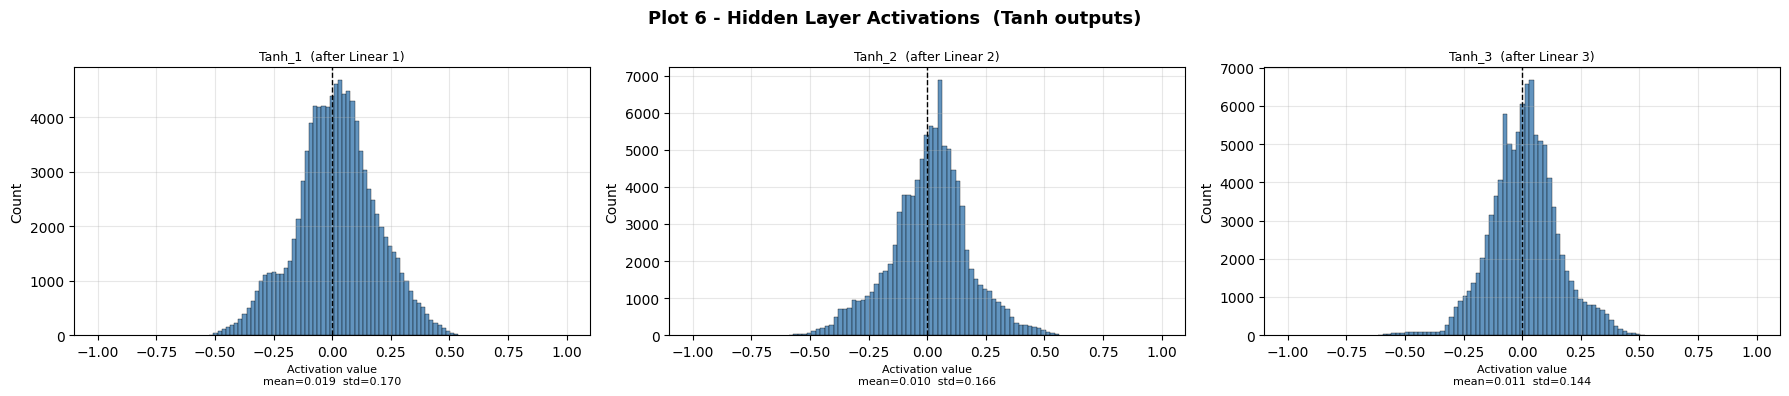

In [ ]:
# -- Plot 6: Hidden Layer Activations — PiezoThermNet -------------------------
# Collect activations from the three hidden Tanh layers using forward hooks.
activations = {}

def _make_hook(name):
    def hook(module, inp, out):
        activations[name] = out.detach().cpu().numpy().ravel()
    return hook

# net.net layout: Linear-Tanh-Linear-Tanh-Linear-Tanh-Linear
# Hidden activations = outputs of Tanh at indices 1, 3, 5
hook_handles = []
tanh_count   = 0
for i, layer in enumerate(net.net):
    if isinstance(layer, torch.nn.Tanh):
        name = f"Tanh_{tanh_count+1}  (after Linear {tanh_count+1})"
        hook_handles.append(layer.register_forward_hook(_make_hook(name)))
        tanh_count += 1

# Run a forward pass with the evaluation grid
net.eval()
with torch.no_grad():
    _ = net(x_g, y_g, z_g)

for h in hook_handles:
    h.remove()

# Plot histograms
n_layers = len(activations)
fig, axes = plt.subplots(1, n_layers, figsize=(6 * n_layers, 4))
if n_layers == 1:
    axes = [axes]

for ax, (layer_name, acts) in zip(axes, activations.items()):
    ax.hist(acts, bins=60, color="steelblue", edgecolor="k", linewidth=0.3, alpha=0.85)
    ax.axvline(0, color="k", linestyle="--", lw=1)
    ax.set_xlabel("Activation value")
    ax.set_ylabel("Count")
    ax.set_title(layer_name, fontsize=9)
    ax.set_xlim(-1.1, 1.1)   # Tanh output in (-1, 1)
    ax.grid(alpha=0.3)
    stats = f"mean={acts.mean():.3f}  std={acts.std():.3f}"
    ax.set_xlabel(f"Activation value\n{stats}", fontsize=8)

plt.suptitle("Plot 6 - Hidden Layer Activations  (Tanh outputs)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
